# Proyecto 1: Fundamentos
## Análisis de bienestar en la población adulta de Bogotá D.C.

**Curso:** Aplicaciones en Ciencia de Datos (DATA-1002)

**Integrantes:**
- Danna Gabriela Castro Villalba
- María Paula Angulo Collantes
- [ Nombre completo 3 ]
- [ Nombre completo 4 ]


---
### Índice
1. [Configuración inicial](#1.-Configuración-inicial)
2. [Entendimiento del problema](#2.-Entendimiento-del-problema)
3. [Preparación de los datos (ETL)](#3.-Preparación-de-los-datos-(ETL))
4. [Análisis descriptivo](#4.-Análisis-descriptivo)
5. [Hallazgos](#5.-Hallazgos)
6. [Reflexión](#6.-Reflexión)

## 1. Configuración inicial
Importar librerías y cargar los datos.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
ruta_datos = "Características y composición del hogar.csv"

df = pd.read_csv(ruta_datos, sep=";", encoding="utf-8")
df.shape

(235350, 78)

In [4]:
df.head()

,DIRECTORIO,SECUENCIA_ENCUESTA,SECUENCIA_P,ORDEN,FEX_C,P6016,P1894,P6020,P6034,P6040,...,P1898,P1899,P3175,P1901,P1903,P1904,P1905,P1927,P3038,P3039
0,8369550,1,1,1,"472,1319014",1,3,2,1,45,...,10.0,5.0,7.0,10.0,6.0,0.0,7.0,6.0,1.0,2.0
1,8369550,2,1,2,"472,1319014",2,3,1,1,25,...,10.0,8.0,7.0,10.0,0.0,0.0,8.0,8.0,2.0,1.0
2,8369550,3,1,3,"472,1319014",3,2,2,1,16,...,10.0,10.0,10.0,10.0,0.0,0.0,10.0,10.0,NaN,NaN
3,8369550,4,1,4,"472,1319014",4,2,1,1,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8369551,1,1,1,"308,8543189",1,3,2,1,62,...,7.0,4.0,7.0,8.0,6.0,2.0,8.0,7.0,1.0,2.0


## 2. Entendimiento del problema

**Pregunta analítica:**

¿Cómo se relaciona la edad con el nivel de satisfacción con la vida de las personas de 18 años o más que vivían en Bogotá hace 12 meses?

**Información necesaria para responder la pregunta:**

Para responder esta pregunta, antes de consultar la base de datos se considera necesario conocer la edad de las personas, con el fin de identificar a la población adulta y posteriormente comparar diferentes grupos de edad. También se necesita conocer el nivel de satisfacción con la vida, ya que esta será la medida utilizada para analizar el bienestar subjetivo de la población.
Además, se requiere información que permita identificar dónde vivía cada persona hace 12 meses, para determinar cuáles corresponden a la población de Bogotá. De esta manera, será posible observar y comparar los niveles de satisfacción con la vida entre personas de diferentes edades dentro de la población adulta definida para el análisis.


## 3. Preparación de los datos (ETL)


In [5]:
pd.set_option('display.max_columns', None)

df = pd.read_csv("Características y composición del hogar.csv", sep=";", encoding="utf-8")

variables_interes = ['DIRECTORIO', 'P6040', 'P1895', 'P6074', 'P753', 'P753S1', 'P753S2']
df_sel = df[variables_interes].copy()
print("Dimensiones df_sel:", df_sel.shape)
df_sel.head()

Dimensiones df_sel: (235350, 7)


,DIRECTORIO,P6040,P1895,P6074,P753,P753S1,P753S2
0,8369550,45,8.0,1.0,NaN,NaN,NaN
1,8369550,25,10.0,1.0,NaN,NaN,NaN
2,8369550,16,10.0,1.0,NaN,NaN,NaN
3,8369550,10,NaN,1.0,NaN,NaN,NaN
4,8369551,62,5.0,2.0,2.0,NaN,NaN


### 3.2 Filtro: personas de 18+ años residentes en Bogotá (últimos 12 meses)


In [6]:
df_adultos = df_sel[df_sel['P6040'] >= 18].copy()
print("Personas de 18+ años (a nivel nacional, antes de filtrar por Bogotá):", df_adultos.shape[0])
print("Filtro de residencia pendiente de aplicar (falta cruzar con 'Datos de la vivienda').")

Personas de 18+ años (a nivel nacional, antes de filtrar por Bogotá): 172025
Filtro de residencia pendiente de aplicar (falta cruzar con 'Datos de la vivienda').


### 3.3 Calidad de los datos


In [7]:
resumen_calidad = pd.DataFrame({
    'nulos': df_adultos[['P6040', 'P1895', 'P6074', 'P753']].isna().sum(),
    '% nulos': (df_adultos[['P6040', 'P1895', 'P6074', 'P753']].isna().mean() * 100).round(2),
})
resumen_calidad

,nulos,% nulos
P6040,0,0.00
P1895,0,0.00
P6074,5293,3.08
P753,130608,75.92


In [8]:
print("Distribución de P1895 (satisfacción con la vida) en adultos 18+:")
print(df_adultos['P1895'].value_counts(dropna=False).sort_index())

Distribución de P1895 (satisfacción con la vida) en adultos 18+:
P1895
0.0       526
1.0       207
2.0       571
3.0      1200
4.0      2112
5.0      7138
6.0     11226
7.0     24693
8.0     50090
9.0     31968
10.0    42294
Name: count, dtype: int64


In [9]:
print("Distribución de P6074 (¿siempre ha vivido en este municipio?) en adultos 18+:")
print(df_adultos['P6074'].value_counts(dropna=False))
print()
print("De quienes se mudaron (P6074 = 2), a dónde se mudaron (P753):")
print(df_adultos.loc[df_adultos['P6074'] == 2, 'P753'].value_counts(dropna=False))

Distribución de P6074 (¿siempre ha vivido en este municipio?) en adultos 18+:
P6074
1.0    130608
2.0     36124
NaN      5293
Name: count, dtype: int64

De quienes se mudaron (P6074 = 2), a dónde se mudaron (P753):
P753
2.0    33820
3.0     2221
4.0       83
Name: count, dtype: int64


## 4. Análisis Descriptivo

### 4.1 Variables numéricas
Media, mediana, mínimo, máximo e interpretación.

In [10]:
df_adultos[['P6040', 'P1895']].describe()

,P6040,P1895
count,172025.000000,172025.000000
mean,45.844046,8.142224
std,17.972662,1.634644
min,18.000000,0.000000
25%,31.000000,7.000000
50%,44.000000,8.000000
75%,60.000000,9.000000
max,108.000000,10.000000


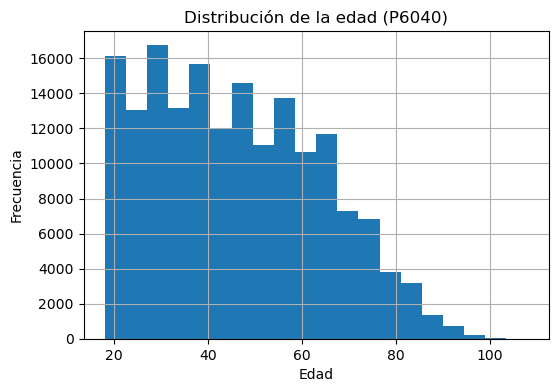

In [11]:
fig, ax = plt.subplots(figsize=(6,4))
df_adultos['P6040'].hist(ax=ax, bins=20)
ax.set_title("Distribución de la edad (P6040)")
ax.set_xlabel("Edad")
ax.set_ylabel("Frecuencia")
plt.show()

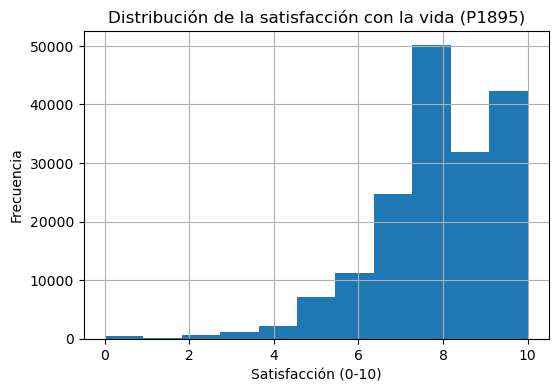

In [12]:
fig, ax = plt.subplots(figsize=(6,4))
df_adultos['P1895'].hist(ax=ax, bins=11)
ax.set_title("Distribución de la satisfacción con la vida (P1895)")
ax.set_xlabel("Satisfacción (0-10)")
ax.set_ylabel("Frecuencia")
plt.show()

### 4.2 Variables categóricas
Frecuencia de las categorías.

In [13]:
bins = [18, 29, 44, 59, 120]
labels = ['18-29', '30-44', '45-59', '60+']
df_adultos['grupo_edad'] = pd.cut(df_adultos['P6040'], bins=bins, labels=labels, right=True, include_lowest=True)

df_adultos['grupo_edad'].value_counts(normalize=True).sort_index().round(3) * 100

grupo_edad
18-29    22.7
30-44    27.8
45-59    24.4
60+      25.1
Name: proportion, dtype: float64

In [14]:
df_adultos.groupby('grupo_edad', observed=True)['P1895'].agg(['count', 'mean', 'median']).round(2)

,count,mean,median
grupo_edad,,,
18-29,39116,8.24,8.0
30-44,47741,8.20,8.0
45-59,42001,8.15,8.0
60+,43167,7.99,8.0


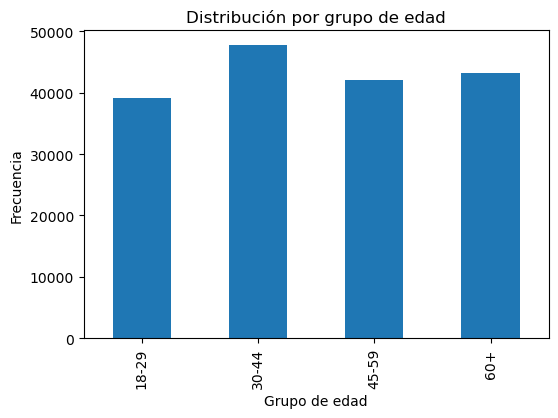

In [15]:
fig, ax = plt.subplots(figsize=(6,4))
df_adultos['grupo_edad'].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("Distribución por grupo de edad")
ax.set_xlabel("Grupo de edad")
ax.set_ylabel("Frecuencia")
plt.show()

### 4.3 Correlación vs. causalidad


In [16]:
correlacion = df_adultos[['P6040', 'P1895']].corr()
correlacion

,P6040,P1895
P6040,1.00000,-0.06375
P1895,-0.06375,1.00000


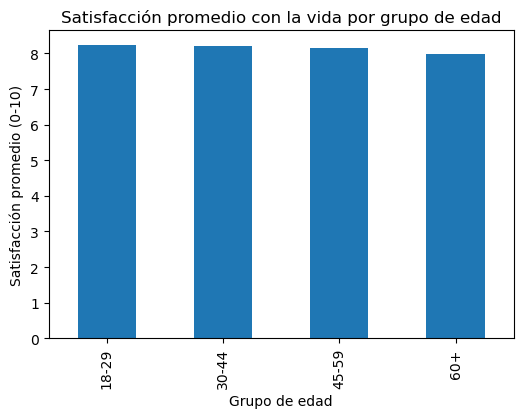

In [17]:
fig, ax = plt.subplots(figsize=(6,4))
df_adultos.groupby('grupo_edad', observed=True)['P1895'].mean().plot(kind="bar", ax=ax)
ax.set_title("Satisfacción promedio con la vida por grupo de edad")
ax.set_xlabel("Grupo de edad")
ax.set_ylabel("Satisfacción promedio (0-10)")
plt.show()

### 4.4 Valores atípicos (outliers)


In [18]:
Q1 = df_adultos['P6040'].quantile(0.25)
Q3 = df_adultos['P6040'].quantile(0.75)
IQR = Q3 - Q1
limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

outliers_edad = df_adultos[(df_adultos['P6040'] < limite_inf) | (df_adultos['P6040'] > limite_sup)]
print(f"Límite superior (IQR): {limite_sup}")
print("Cantidad de outliers en edad:", outliers_edad.shape[0])
outliers_edad[['P6040', 'P1895']]

Límite superior (IQR): 103.5
Cantidad de outliers en edad: 5


,P6040,P1895
49453,105,3.0
61584,104,9.0
114404,104,8.0
118634,105,5.0
147897,108,10.0


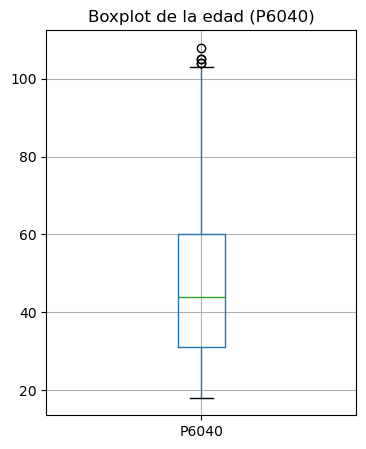

In [19]:
fig, ax = plt.subplots(figsize=(4,5))
df_adultos.boxplot(column="P6040", ax=ax)
ax.set_title("Boxplot de la edad (P6040)")
plt.show()

## 5. Hallazgos

> [ ¿Qué le pueden decir a la Alcaldía sobre el tema analizado? ¿Cómo responden estos hallazgos a la
> pregunta analítica? ¿Qué no se puede concluir con la información disponible y qué análisis adicional
> haría falta? ]

## 6. Reflexión

**¿Qué fue lo más difícil al transformar una necesidad de información en una pregunta analítica?**
> [ Respuesta del equipo ]

**¿Qué decisiones tuvieron que tomar durante la selección y preparación de los datos, y cómo influyeron en el análisis?**
> [ Respuesta del equipo ]